In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
#from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm
import xesmf as xe

In [2]:
z500_SON=xr.open_dataset('~/work/ERA5_dyn_data_ready/z500_SON.nc')
z500_DJF=xr.open_dataset('~/work/ERA5_dyn_data_ready/z500_DJF.nc')

def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('../data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('../data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('../data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('../data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

In [3]:
##SON data
ds_SON = xr.merge([z500_SON, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([z500_DJF, era_DJF_LaPlata_array])

In [4]:
from Functions import lin_model_fast, sensitivity_analysis_fast, conditioning_everything_fast
from Functions import modified_colorbar, plot_map_circ, subplots_map_circ

In [5]:
##separate early and late
ds_early_SON=ds_SON.where(ds_SON['VB_class']=='Early')
ds_late_SON=ds_SON.where(ds_SON['VB_class']=='Late')
z500_SON_direct_early=conditioning_everything_fast(ds_early_SON,['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], \
                                                   'Z500', whole_period=True, total_eff=False)
z500_SON_direct_late=conditioning_everything_fast(ds_late_SON,['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], \
                                                   'Z500', whole_period=True, total_eff=False)

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
A_SAM done
S_SAM done


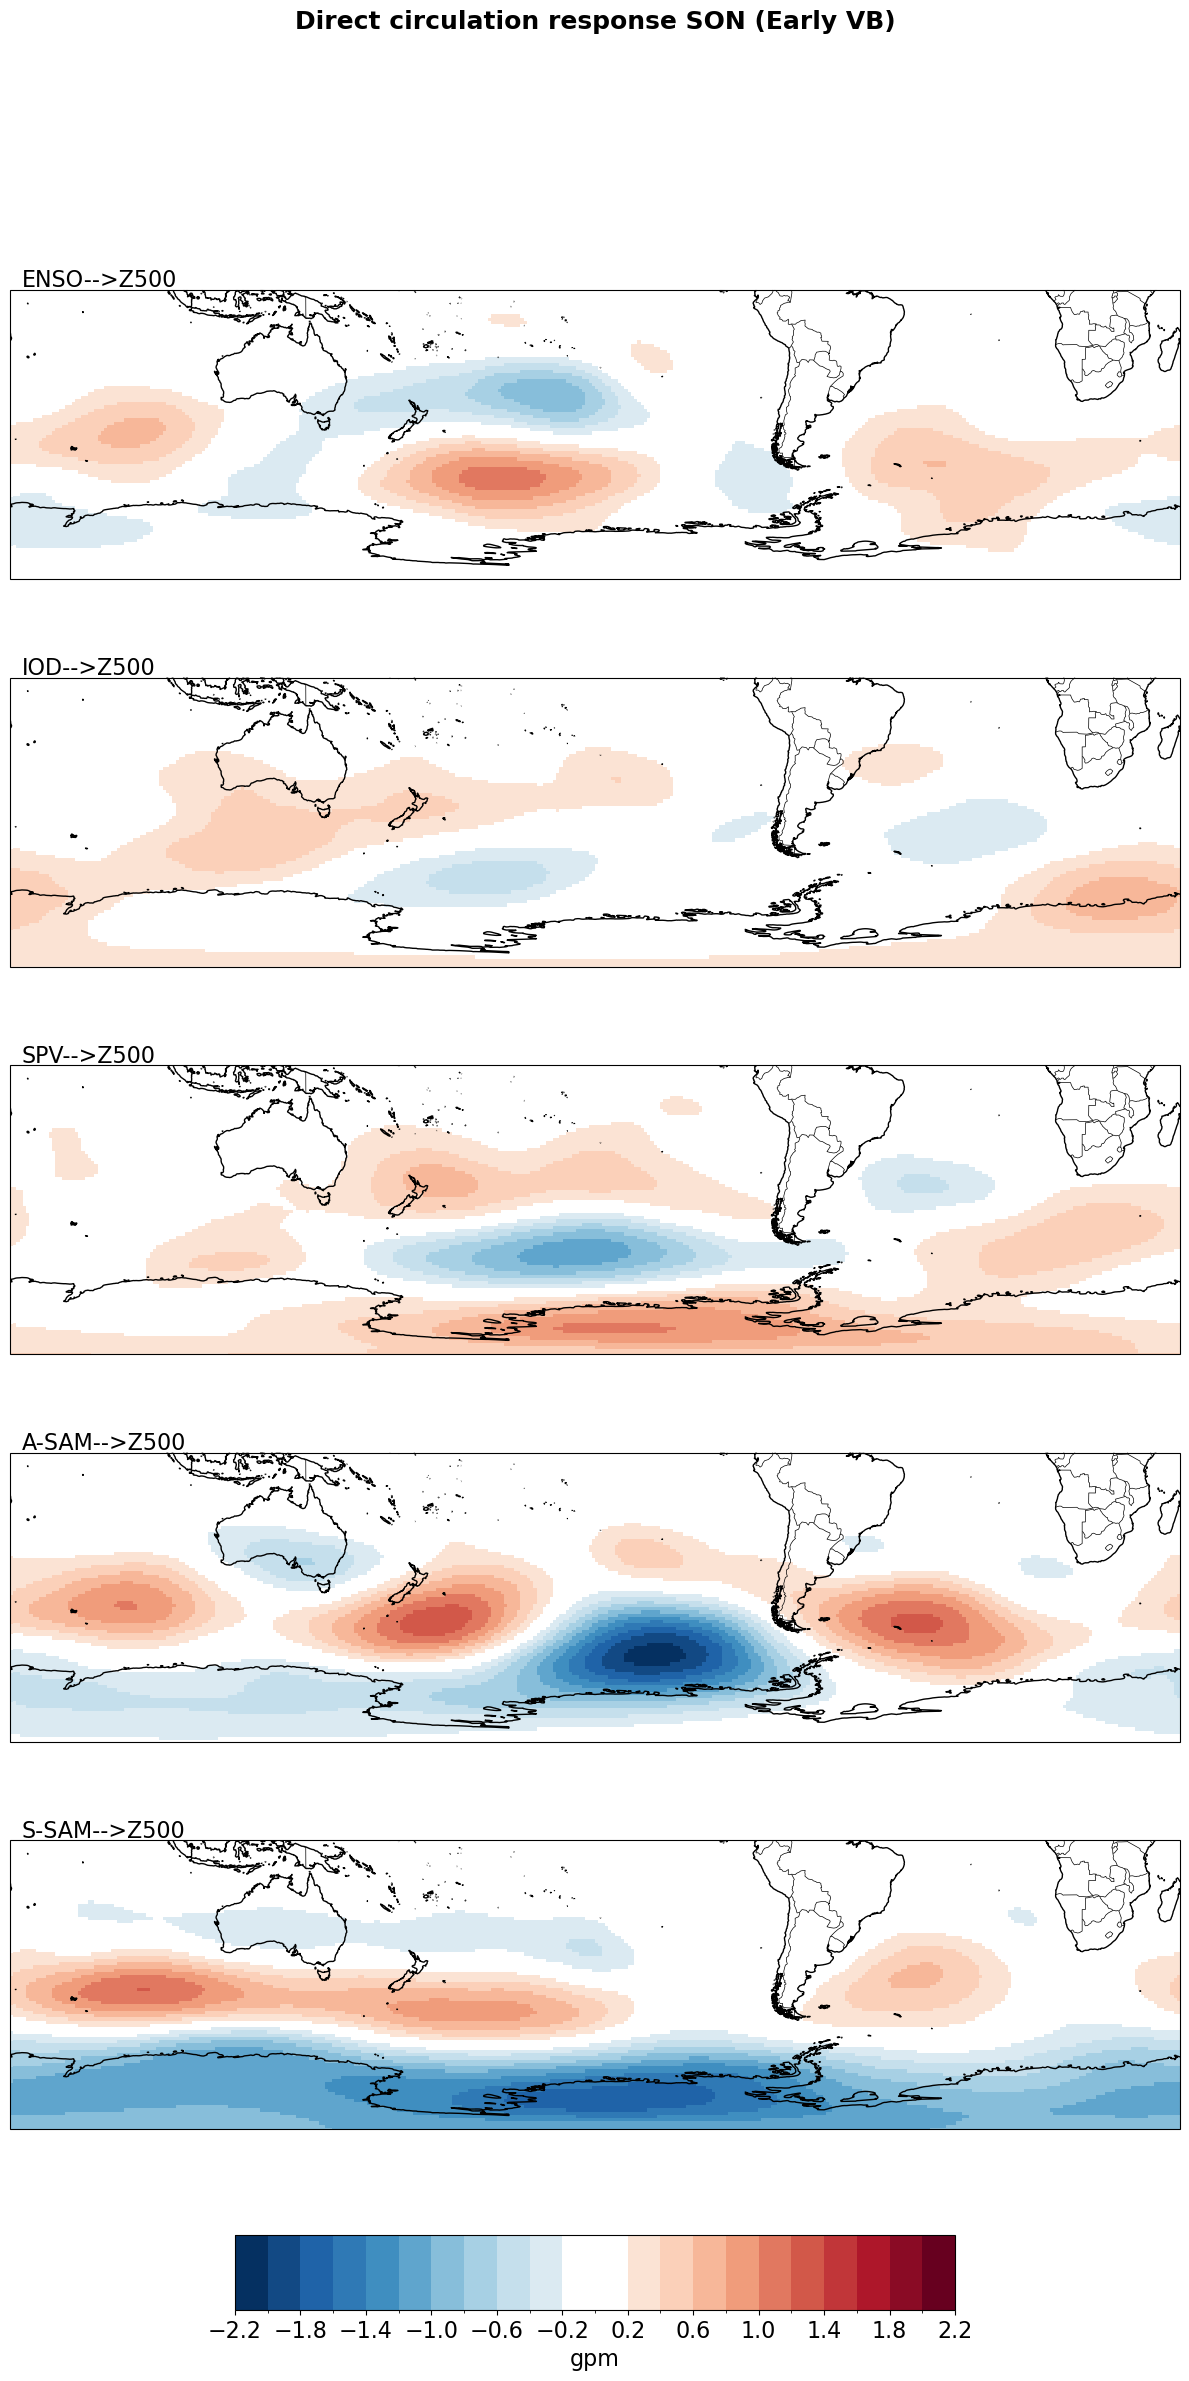

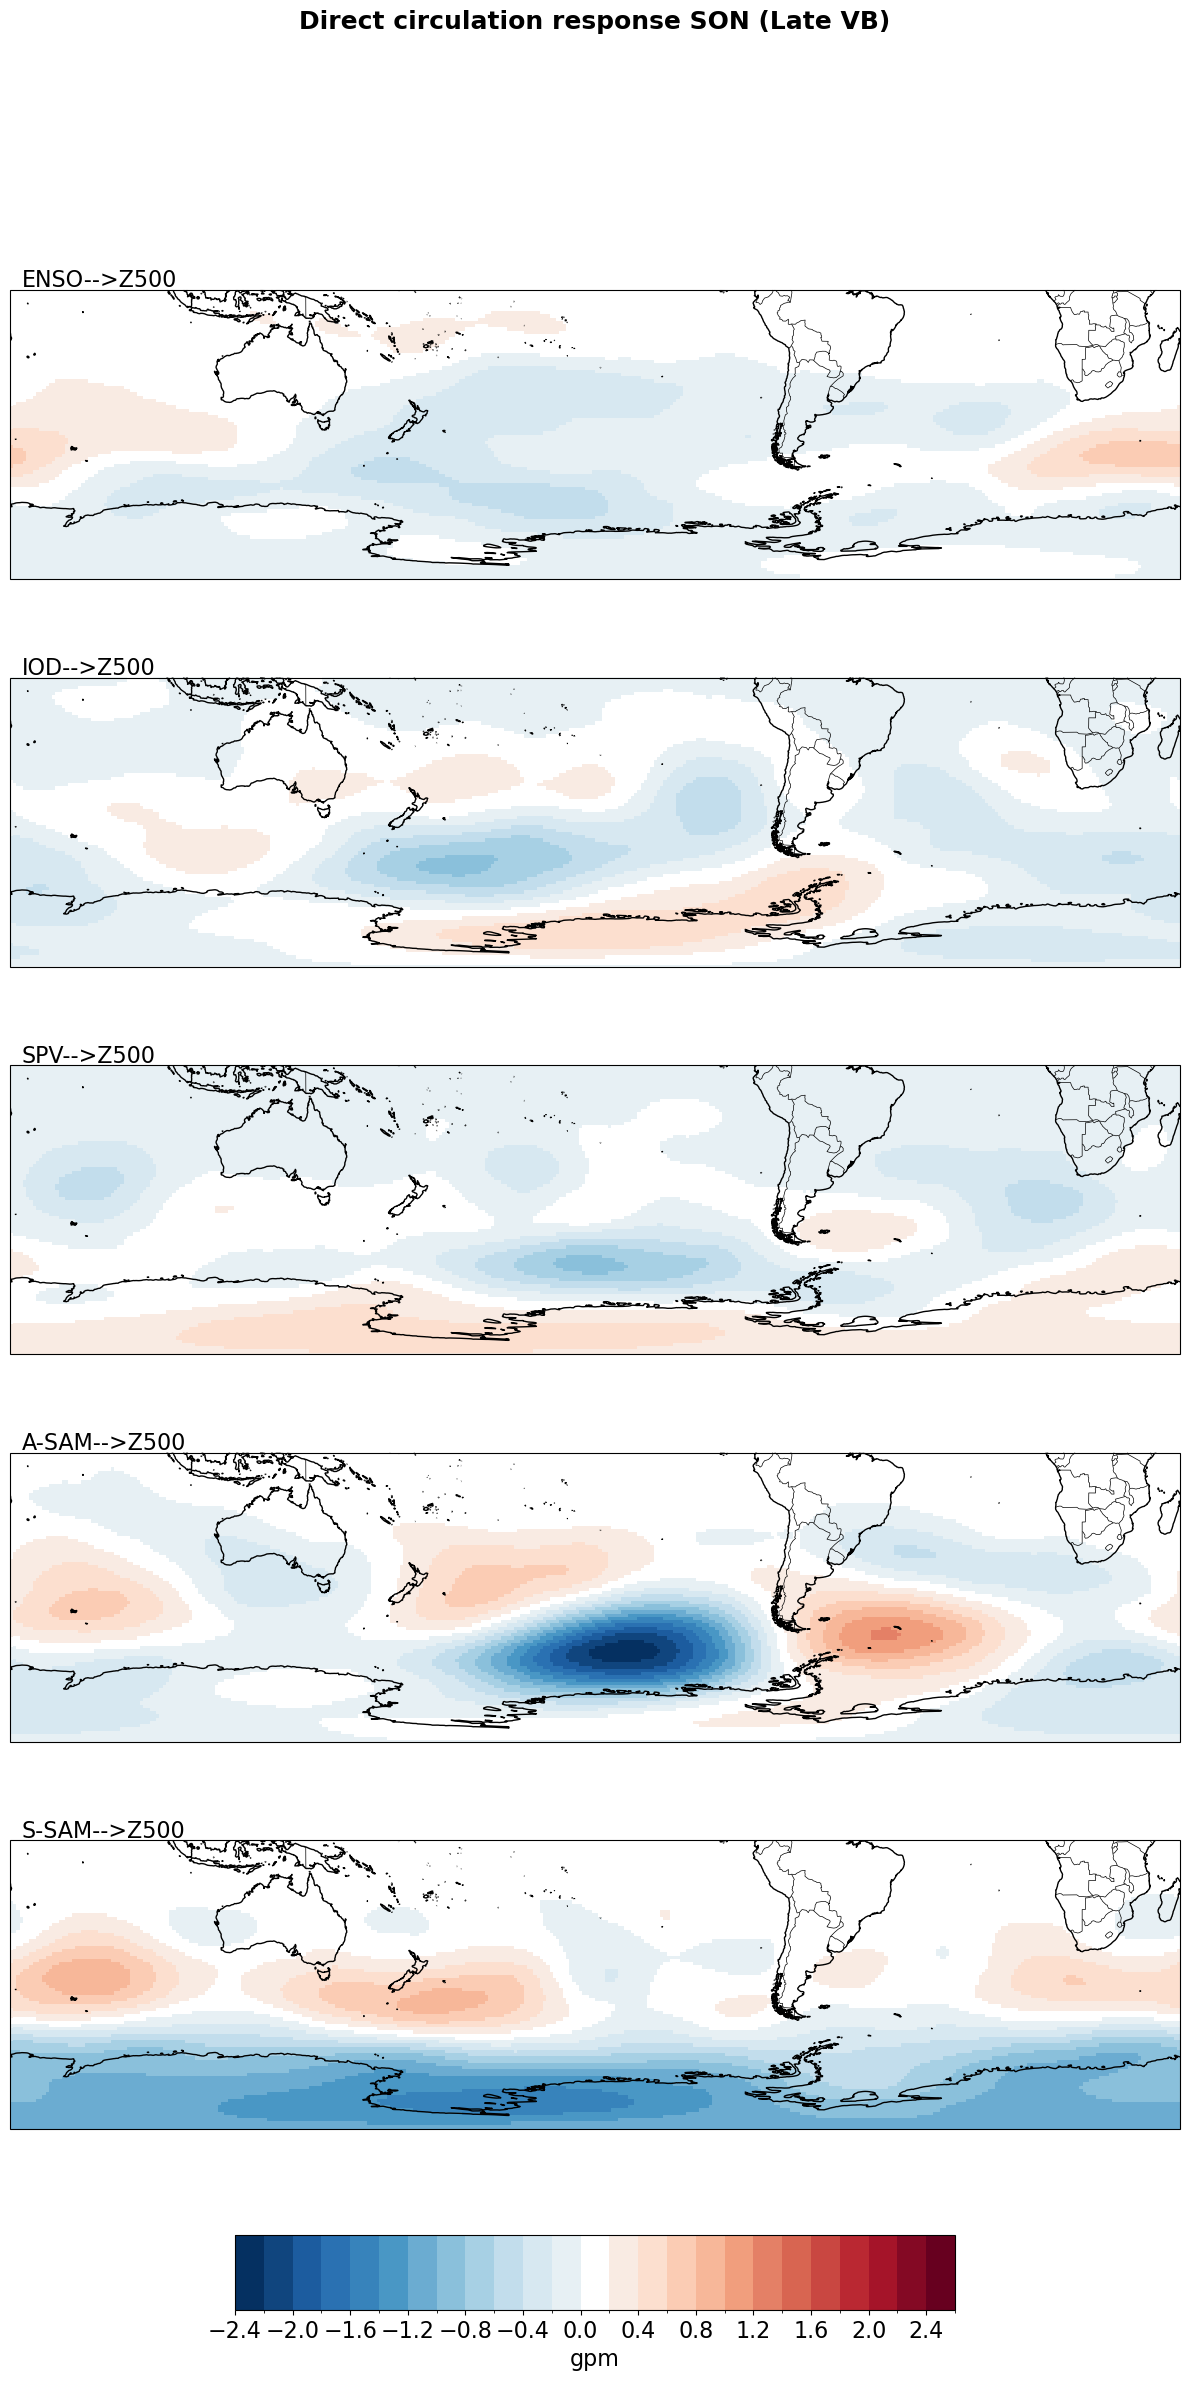

In [6]:
plt.close('all')
subplots_map_circ(z500_SON_direct_early, ['ENSO-->Z500', 'IOD-->Z500', 'SPV-->Z500', 'A-SAM-->Z500', 'S-SAM-->Z500'],\
             unit='gpm', steps=0.2, heading='Direct circulation response SON (Early VB)')
subplots_map_circ(z500_SON_direct_late, ['ENSO-->Z500', 'IOD-->Z500', 'SPV-->Z500', 'A-SAM-->Z500', 'S-SAM-->Z500'],\
             unit='gpm', steps=0.2, heading='Direct circulation response SON (Late VB)')

In [9]:
ds_early_DJF=ds_DJF.where(ds_DJF['VB_class']=='Early')
ds_late_DJF=ds_DJF.where(ds_DJF['VB_class']=='Late')
z500_DJF_direct_early=conditioning_everything_fast(ds_early_DJF,['ENSO', 'IOBW', 'A_SAM', 'S_SAM'], \
                                                   'Z500', whole_period=True, total_eff=False)
z500_DJF_direct_late=conditioning_everything_fast(ds_late_DJF,['ENSO', 'IOBW', 'A_SAM', 'S_SAM'], \
                                                   'Z500', whole_period=True, total_eff=False)

ENSO done
IOBW done
A_SAM done
S_SAM done
ENSO done
IOBW done
A_SAM done
S_SAM done


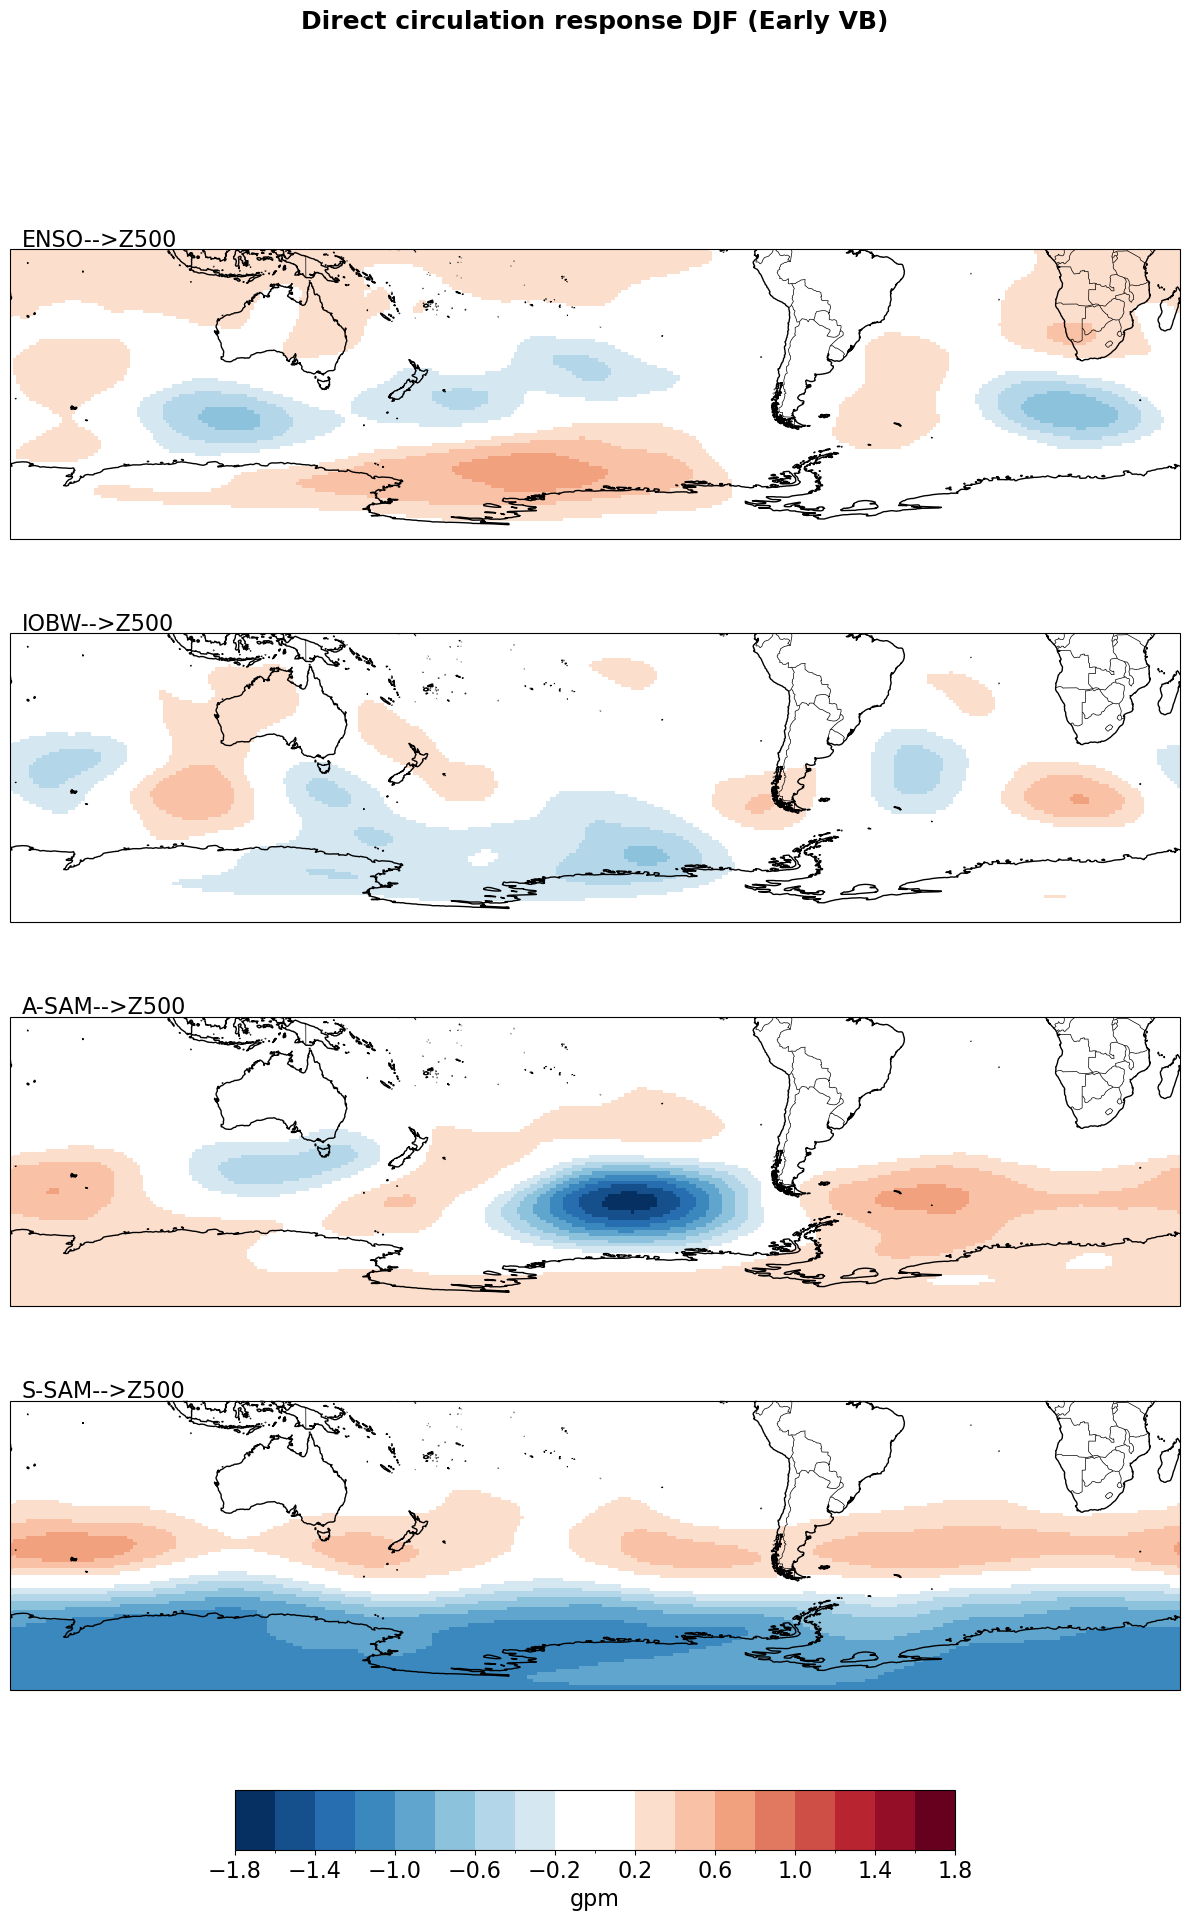

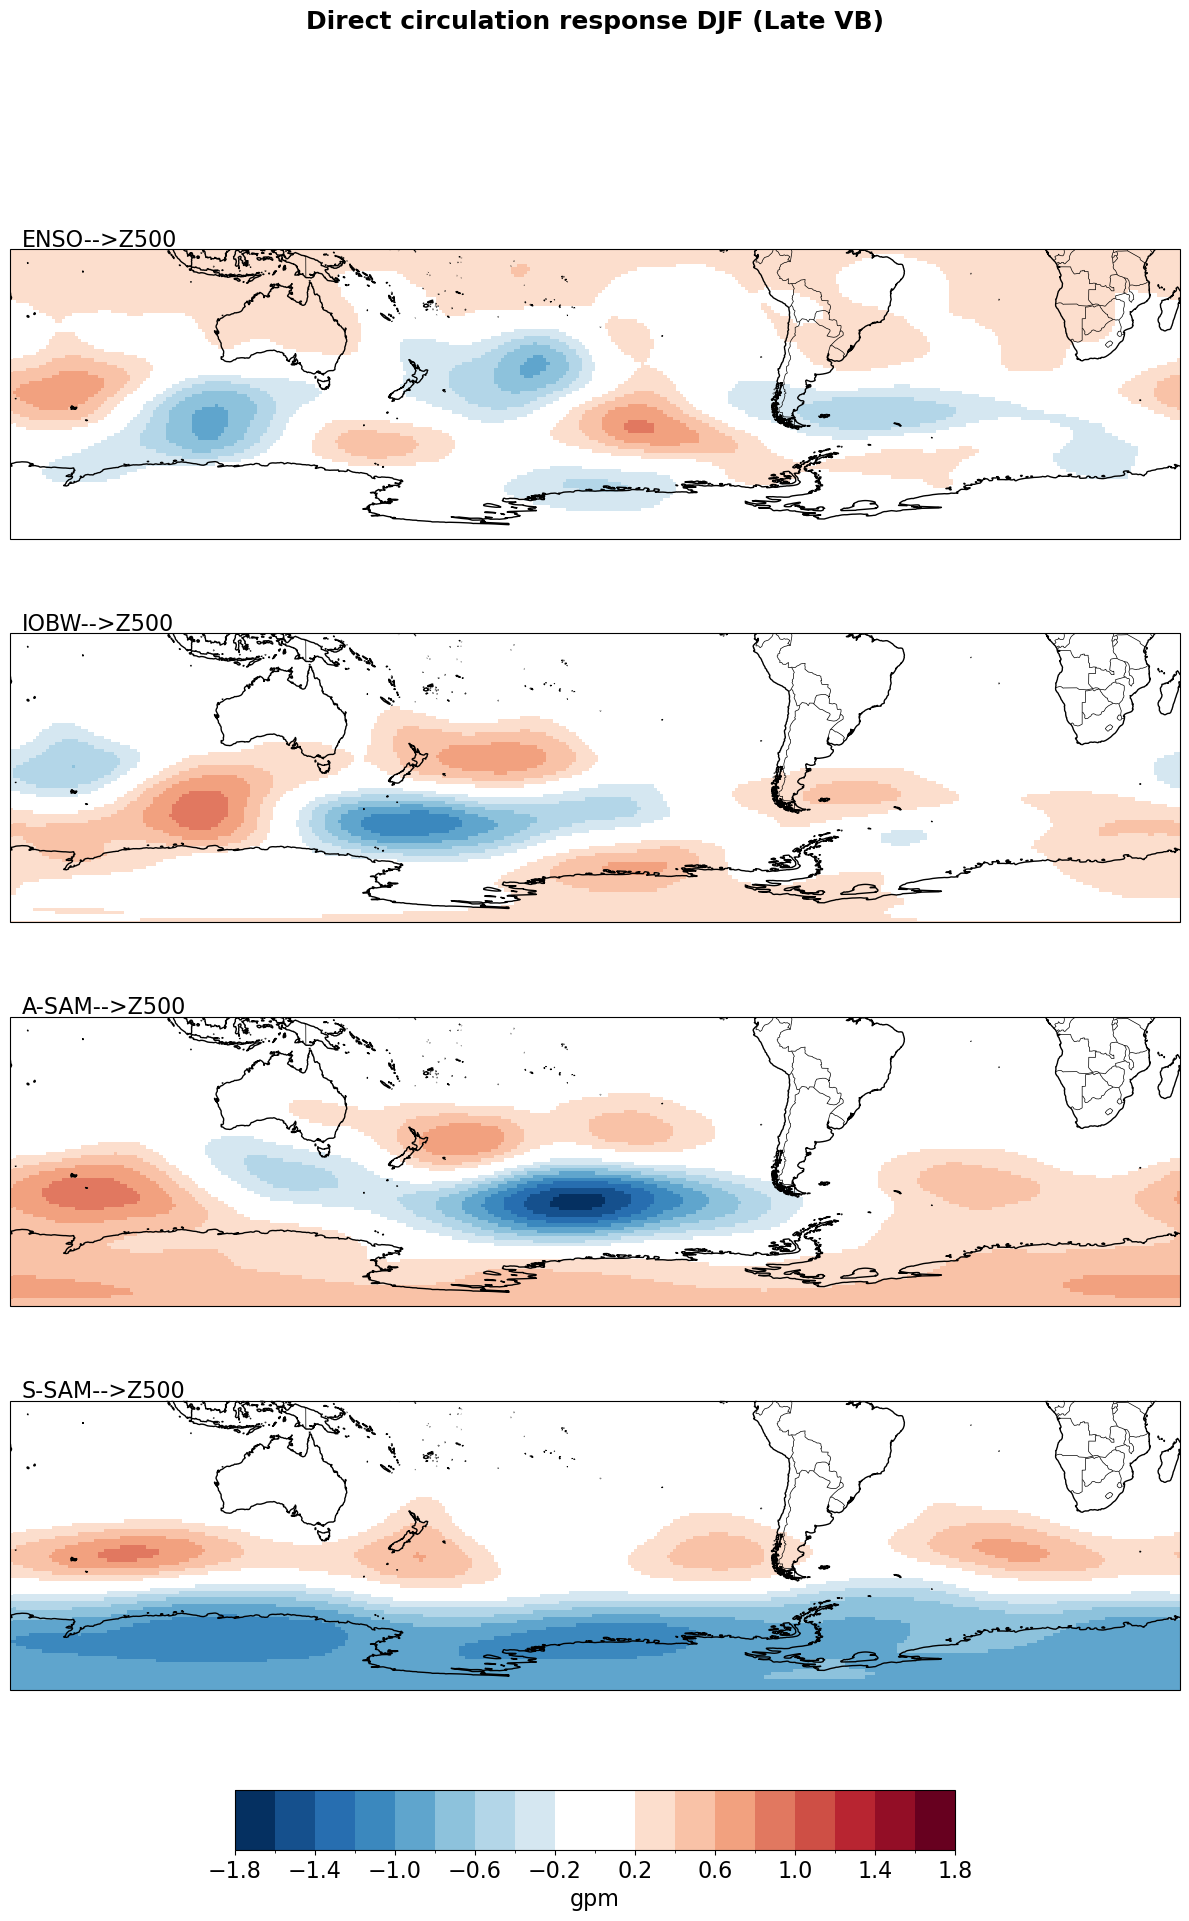

In [10]:
subplots_map_circ(z500_DJF_direct_early, ['ENSO-->Z500', 'IOBW-->Z500', 'A-SAM-->Z500', 'S-SAM-->Z500'],\
             unit='gpm', steps=0.2, heading='Direct circulation response DJF (Early VB)')
subplots_map_circ(z500_DJF_direct_late, ['ENSO-->Z500', 'IOBW-->Z500', 'A-SAM-->Z500', 'S-SAM-->Z500'],\
             unit='gpm', steps=0.2, heading='Direct circulation response DJF (Late VB)')